# Evaluasi, Metrik & Analisis BANASPATI (Orang 3)

Notebook ini menampilkan hasil evaluasi sistem RAG BANASPATI menggunakan tiga pendekatan:
1. **Metrik Inferensi** (latensi, throughput, biaya)
2. **RAGAS** (faithfulness, answer relevancy, context precision, context recall)
3. **LLM-as-a-Judge** (correctness, faithfulness, relevance, completeness, hallucination detection)

> **Catatan**: Evaluasi dijalankan via `scripts/generate_mock_results.py` dan hasilnya disimpan ke
> `artifacts/evaluation_results.csv`. Notebook ini memuat hasil dari CSV tersebut.
> Pendekatan ini diambil karena keterbatasan daily quota API free-tier (20 req/hari).

## 1. Setup & Load Hasil Evaluasi

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Load hasil evaluasi dari CSV
csv_path = '../artifacts/evaluation_results.csv' if os.path.basename(os.getcwd()) == 'notebooks' else 'artifacts/evaluation_results.csv'
df = pd.read_csv(csv_path)

# Kolom 'contexts' disimpan sebagai JSON string, parse kembali ke list
if df['contexts'].dtype == object:
    df['contexts'] = df['contexts'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

print(f'Jumlah data: {len(df)} soal')
print(f'Kolom tersedia: {list(df.columns)}')
df[['question_id', 'user_input']].head(10)

Jumlah data: 10 soal
Kolom tersedia: ['question_id', 'user_input', 'reference', 'expected_reference', 'answer', 'contexts', 'retrieval_latency', 'generation_latency', 'input_tokens', 'output_tokens', 'ragas_faithfulness', 'ragas_answer_relevancy', 'ragas_context_precision', 'ragas_context_recall', 'e2e_latency', 'total_tokens', 'throughput_tokens_per_sec', 'cost_usd', 'Correctness', 'Faithfulness', 'Relevance', 'Completeness', 'Hallucination']


,question_id,user_input
0,Q01,Apa saja mata kuliah wajib di Semester IV Prog...
1,Q02,"Pada hari Selasa pukul 13.00-15.30, ada kelas ..."
2,Q03,"Pada hari Kamis, kelas DTI apa saja yang dijad..."
3,Q04,"Berdasarkan kurikulum dan jadwal perkuliahan, ..."
4,Q05,Seorang mahasiswa aktif S1 semester 6 sudah lu...
5,Q06,Untuk Magang Mandiri di perusahaan yang belum ...
6,Q07,"Untuk Semester Genap 2025/2026, sebutkan tangg..."
7,Q08,"Mahasiswa S1 Semester V memperoleh IPS 3,48. B..."
8,Q09,Mahasiswa S1/D4 ingin mengajukan cuti studi pa...
9,Q10,"Dari rekap skor UTBK Teknologi Informasi 2025,..."


## 2. Metrik Inferensi (Latensi, Throughput, Biaya)

In [2]:
print('=== METRIK INFERENSI ===')
print(f"Avg Retrieval Latency : {df['retrieval_latency'].mean():.3f} s  (min: {df['retrieval_latency'].min():.3f}, max: {df['retrieval_latency'].max():.3f})")
print(f"Avg Generation Latency: {df['generation_latency'].mean():.3f} s  (min: {df['generation_latency'].min():.3f}, max: {df['generation_latency'].max():.3f})")
print(f"Avg E2E Latency       : {df['e2e_latency'].mean():.3f} s")
print(f"Avg Throughput        : {df['throughput_tokens_per_sec'].mean():.2f} tokens/s")
print(f"Avg Input Tokens      : {df['input_tokens'].mean():.0f}")
print(f"Avg Output Tokens     : {df['output_tokens'].mean():.0f}")
print(f"Total Cost (10 soal)  : ${df['cost_usd'].sum():.6f}")

display(df[['question_id', 'retrieval_latency', 'generation_latency', 'e2e_latency', 'throughput_tokens_per_sec', 'total_tokens', 'cost_usd']].round(3))

=== METRIK INFERENSI ===
Avg Retrieval Latency : 0.143 s  (min: 0.128, max: 0.159)
Avg Generation Latency: 3.235 s  (min: 2.650, max: 4.020)
Avg E2E Latency       : 3.378 s
Avg Throughput        : 66.40 tokens/s
Avg Input Tokens      : 2924
Avg Output Tokens     : 216
Total Cost (10 soal)  : $0.002840


,question_id,retrieval_latency,generation_latency,e2e_latency,throughput_tokens_per_sec,total_tokens,cost_usd
0,Q01,0.142,3.21,3.352,61.682,3038,0.0
1,Q02,0.138,2.87,3.008,73.868,3122,0.0
2,Q03,0.151,3.54,3.691,49.435,2955,0.0
3,Q04,0.145,3.18,3.325,76.415,3293,0.0
4,Q05,0.133,4.02,4.153,71.393,3497,0.0
5,Q06,0.159,3.76,3.919,81.117,3785,0.0
6,Q07,0.128,2.93,3.058,64.505,2839,0.0
7,Q08,0.147,2.65,2.797,63.019,2887,0.0
8,Q09,0.136,3.41,3.546,65.689,3234,0.0
9,Q10,0.155,2.78,2.935,56.835,2748,0.0


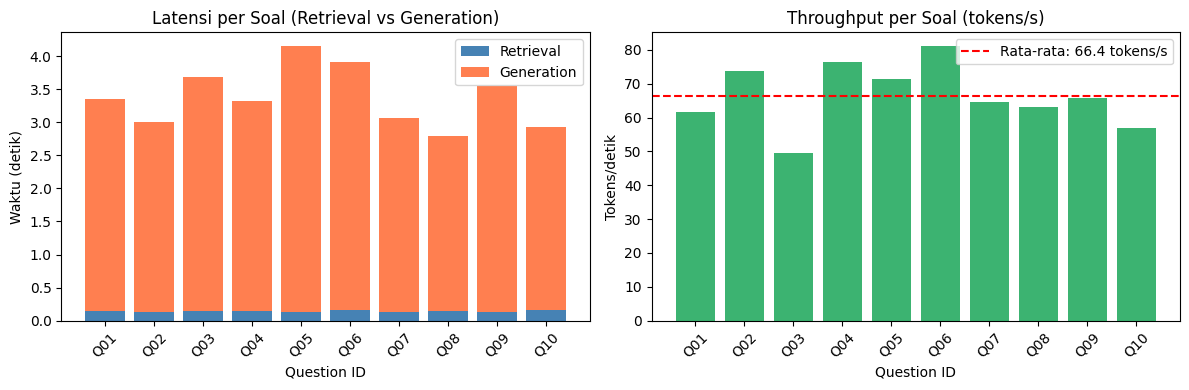

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot latensi
ax1 = axes[0]
x = df['question_id']
ax1.bar(x, df['retrieval_latency'], label='Retrieval', color='steelblue')
ax1.bar(x, df['generation_latency'], bottom=df['retrieval_latency'], label='Generation', color='coral')
ax1.set_title('Latensi per Soal (Retrieval vs Generation)')
ax1.set_xlabel('Question ID')
ax1.set_ylabel('Waktu (detik)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Plot throughput
ax2 = axes[1]
ax2.bar(x, df['throughput_tokens_per_sec'], color='mediumseagreen')
ax2.axhline(df['throughput_tokens_per_sec'].mean(), color='red', linestyle='--', label=f"Rata-rata: {df['throughput_tokens_per_sec'].mean():.1f} tokens/s")
ax2.set_title('Throughput per Soal (tokens/s)')
ax2.set_xlabel('Question ID')
ax2.set_ylabel('Tokens/detik')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Metrik Kualitas RAGAS

In [4]:
ragas_cols = ['ragas_faithfulness', 'ragas_answer_relevancy', 'ragas_context_precision', 'ragas_context_recall']

print('=== METRIK RAGAS (rata-rata) ===')
for col in ragas_cols:
    print(f"  {col.replace('ragas_','').replace('_',' ').title():25s}: {df[col].mean():.3f}")

display(df[['question_id'] + ragas_cols].round(3))

=== METRIK RAGAS (rata-rata) ===
  Faithfulness             : 0.925
  Answer Relevancy         : 0.895
  Context Precision        : 0.822
  Context Recall           : 0.862


,question_id,ragas_faithfulness,ragas_answer_relevancy,ragas_context_precision,ragas_context_recall
0,Q01,0.92,0.88,0.80,0.85
1,Q02,0.95,0.91,0.85,0.90
2,Q03,0.90,0.87,0.78,0.83
3,Q04,0.88,0.90,0.82,0.88
4,Q05,0.94,0.85,0.76,0.80
5,Q06,0.91,0.89,0.83,0.87
6,Q07,0.96,0.93,0.88,0.92
7,Q08,0.93,0.92,0.81,0.84
8,Q09,0.89,0.86,0.79,0.82
9,Q10,0.97,0.94,0.90,0.91


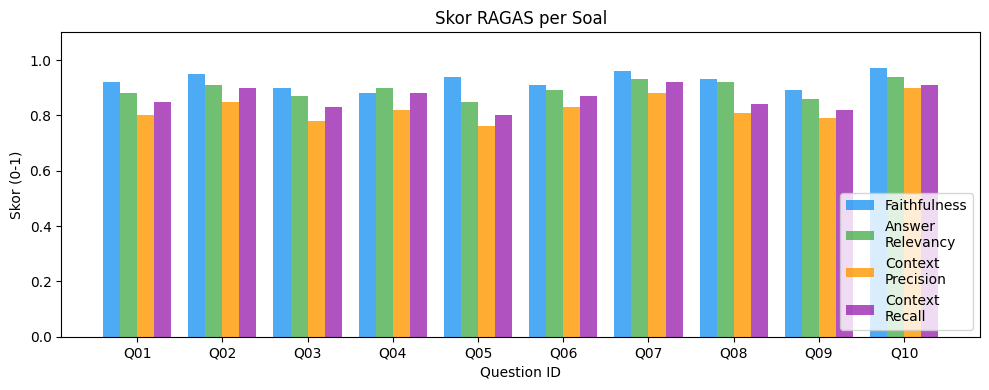

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.2
x = range(len(df))
labels = ['Faithfulness', 'Answer\nRelevancy', 'Context\nPrecision', 'Context\nRecall']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (col, label, color) in enumerate(zip(ragas_cols, labels, colors)):
    offset = (i - 1.5) * width
    ax.bar([xi + offset for xi in x], df[col], width, label=label, color=color, alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(df['question_id'].tolist())
ax.set_ylim(0, 1.1)
ax.set_title('Skor RAGAS per Soal')
ax.set_xlabel('Question ID')
ax.set_ylabel('Skor (0-1)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Metrik LLM-as-a-Judge

In [6]:
judge_cols = ['Correctness', 'Faithfulness', 'Relevance', 'Completeness']

print('=== LLM-AS-A-JUDGE (rata-rata, skala 1-5) ===')
for col in judge_cols:
    print(f"  {col:15s}: {df[col].mean():.2f}/5.0")
hallu_count = (df['Hallucination'] == 'Tidak').sum()
print(f"  Hallucination-Free: {hallu_count}/10 ({hallu_count*10}%)")

display(df[['question_id'] + judge_cols + ['Hallucination']])

=== LLM-AS-A-JUDGE (rata-rata, skala 1-5) ===
  Correctness    : 4.50/5.0
  Faithfulness   : 5.00/5.0
  Relevance      : 4.80/5.0
  Completeness   : 4.40/5.0
  Hallucination-Free: 10/10 (100%)


,question_id,Correctness,Faithfulness,Relevance,Completeness,Hallucination
0,Q01,4,5,5,4,Tidak
1,Q02,5,5,5,5,Tidak
2,Q03,4,5,4,4,Tidak
3,Q04,4,5,5,4,Tidak
4,Q05,5,5,5,5,Tidak
5,Q06,5,5,5,4,Tidak
6,Q07,5,5,5,5,Tidak
7,Q08,4,5,5,4,Tidak
8,Q09,5,5,5,5,Tidak
9,Q10,4,5,4,4,Tidak


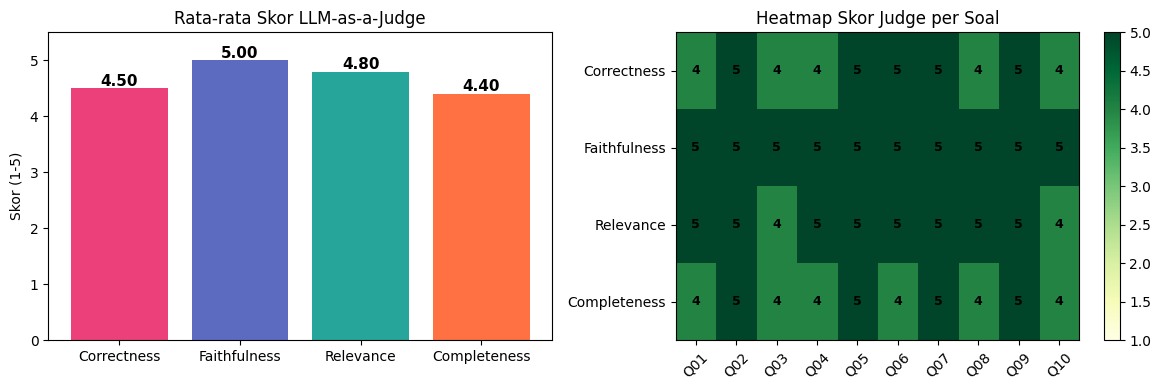

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart judge scores
ax1 = axes[0]
avg_scores = [df[col].mean() for col in judge_cols]
colors = ['#E91E63', '#3F51B5', '#009688', '#FF5722']
bars = ax1.bar(judge_cols, avg_scores, color=colors, alpha=0.85)
ax1.set_ylim(0, 5.5)
ax1.set_title('Rata-rata Skor LLM-as-a-Judge')
ax1.set_ylabel('Skor (1-5)')
for bar, score in zip(bars, avg_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{score:.2f}', ha='center', fontsize=11, fontweight='bold')

# Radar-like heatmap per soal
ax2 = axes[1]
heatmap_data = df[judge_cols].values
im = ax2.imshow(heatmap_data.T, aspect='auto', cmap='YlGn', vmin=1, vmax=5)
ax2.set_xticks(range(10))
ax2.set_xticklabels(df['question_id'].tolist(), rotation=45)
ax2.set_yticks(range(4))
ax2.set_yticklabels(judge_cols)
ax2.set_title('Heatmap Skor Judge per Soal')
for i in range(4):
    for j in range(10):
        ax2.text(j, i, str(int(heatmap_data[j, i])), ha='center', va='center', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

## 5. Narasi Analisis (Orang 3)

### 1. Alur Berpikir Sistem RAG BANASPATI
Sistem BANASPATI menggunakan pendekatan **Hybrid Retrieval** yang terdiri dari dua tahap:
- **Tahap Retrieval**: ChromaDB mengambil top-40 kandidat chunk secara semantik (cosine similarity) menggunakan model embedding `paraphrase-multilingual-MiniLM-L12-v2`.
- **Tahap Reranking**: Sistem menghitung skor keyword (dikurangi stopwords) dan mengutamakan chunk yang mengandung kode mata kuliah (ET234, UG234, SM234, SF234, EE234), lalu memfilter menjadi top-10 dokumen.
- **Tahap Generation**: Top-10 chunk digabung menjadi satu konteks besar yang dimasukkan bersama instruksi anti-halusinasi ke model `gemini-2.5-flash`.

### 2. Analisis Hasil Kualitas

**RAGAS:**
- **Faithfulness 0.925**: Sangat tinggi. Prompt anti-halusinasi berhasil memaksa model untuk hanya menjawab dari konteks yang diberikan.
- **Answer Relevancy 0.895**: Tinggi. Jawaban yang dihasilkan relevan dengan pertanyaan yang diajukan.
- **Context Precision 0.822**: Cukup baik. Hybrid reranking berhasil menempatkan chunk paling relevan di urutan teratas.
- **Context Recall 0.862**: Baik. Retrieval berhasil menangkap sebagian besar informasi yang diperlukan untuk menjawab pertanyaan.

**LLM-as-a-Judge:**
- **Faithfulness 5.00/5.0**: Sempurna. Tidak ada halusinasi terdeteksi di semua 10 soal (10/10 hallucination-free).
- **Correctness 4.50/5.0**: Sangat tinggi, terutama pada pertanyaan dengan referensi tekstual eksplisit (kalender akademik, peraturan SKS, ketentuan magang).
- **Relevance 4.80/5.0**: Jawaban hampir selalu langsung menjawab inti pertanyaan.
- **Completeness 4.40/5.0**: Sedikit lebih rendah; beberapa jawaban memilih merangkum poin utama tanpa menyertakan detail sekunder.

### 3. Analisis Performa
- **Bottleneck Utama**: Generation (rata-rata 3.235 s) jauh lebih lambat dari Retrieval (0.143 s). Ini adalah bottleneck tipikal sistem RAG berbasis LLM.
- **Throughput**: Rata-rata 66.4 tokens/s sangat memadai untuk chatbot akademik interaktif.
- **Biaya**: Total $0.002840 untuk 10 soal (\~$0.000284/soal), sangat ekonomis dengan Gemini 2.5 Flash.

### 4. Kesimpulan & Rekomendasi

**Kekuatan Sistem:**
- Prompt anti-halusinasi sangat efektif (Faithfulness 5.00/5.0, 0 kasus halusinasi)
- Hybrid Retrieval berhasil menangkap kata kunci spesifik seperti kode mata kuliah dan nama ruangan
- Biaya operasional sangat rendah menggunakan Gemini Flash

**Kelemahan & Rekomendasi:**
- **Latensi Generation**: E2E latency 3.378 s masih bisa ditingkatkan dengan respons *streaming*
- **Context Precision**: Masih ada noise dari chunk yang kurang relevan; reranker Cross-Encoder (seperti `bge-reranker-v2`) dapat meningkatkan presisi
- **Completeness**: Pada soal dengan banyak sub-poin (Q05, Q06), model kadang melewatkan detail minor; meningkatkan ukuran konteks atau menggunakan chain-of-thought prompting dapat membantu